# Leave-one-out solver analysis — window write-up (M4)

Aggregates the reports written by `loo analyse --out` into the PLAN §7 comparison:
headline table, medians beside the sums, and whale concentration. Everything here is
post-processing of those JSONs — the only DB access is the stablecoin prices behind
the USD columns, and the notebook runs without it (the USD columns are then omitted).

**Signs:** every delta is **counterfactual − actual** (without-solver minus
with-solver), so the numbers read as what the removal scenario changes: negative
Δsurplus means users would have received less, positive Δrewards means the protocol
would have paid more. Turning a change into a *value of the solver* is deliberately
left to the reader.

Generate the inputs (each run takes ~5 minutes; `inherited` is required,
`assume-settled` optional):

```bash
for rule in inherited assume-settled; do
  uv run loo analyse --solver Fractal --start 2026-08-01 --end 2026-08-04 \
      --outcome-rule $rule --out out/fractal-$rule.json
  uv run loo analyse --solver Sector --start 2026-08-01 --end 2026-08-04 \
      --outcome-rule $rule --out out/sector-$rule.json
done
```

The same table on the command line: `uv run loo compare out/*.json`.

Background: [PLAN.md](../PLAN.md) (milestones, design decisions D1–D16),
[docs/winner-selection.md](../docs/winner-selection.md),
[docs/rewards.md](../docs/rewards.md),
[docs/analytics-db.md](../docs/analytics-db.md).

In [1]:
from pathlib import Path

import pandas as pd

from loo import aggregate

REPORT_DIR = Path("..") / "out"

reports = [aggregate.load_report(str(p)) for p in sorted(REPORT_DIR.glob("*.json"))]
if not reports:
    raise FileNotFoundError(
        f"no analyse reports in {REPORT_DIR.resolve()} — generate them with the "
        f"commands in the cell above"
    )
windows = aggregate.group_reports(reports)

pd.DataFrame(
    {
        "solver": r.solver,
        "window": f"{r.start}..{r.end}",
        "network": r.network,
        "mode": r.mode,
        "outcome rule": r.outcome_rule,
        "auctions analysed": r.analysed,
        "changed auctions": len(r.moves),
        "file": Path(r.path).name,
    }
    for r in reports
)

,solver,window,network,mode,outcome rule,auctions analysed,changed auctions,file
0,Fractal,2026-08-01..2026-08-04,mainnet,score,assume-settled,7701,1275,fractal-assume-settled.json
1,Fractal,2026-08-01..2026-08-04,mainnet,score,inherited,7701,1275,fractal-inherited.json
2,Fractal,2026-08-01..2026-08-04,mainnet,score,observed,7701,1275,fractal-observed.json
3,Sector,2026-08-01..2026-08-04,mainnet,score,assume-settled,7701,1780,sector-assume-settled.json
4,Sector,2026-08-01..2026-08-04,mainnet,score,inherited,7701,1780,sector-inherited.json
5,Sector,2026-08-01..2026-08-04,mainnet,score,observed,7701,1780,sector-observed.json


In [2]:
# USD rates, implied per auction by the median stablecoin price in the auction's own
# price vector (D15). Skipped gracefully when the DB is unreachable.
usd_by_network = {}
try:
    from loo import db, extract

    for network in sorted({r.network for r in reports}):
        auction_ids = sorted(
            {m.auction_id for r in reports if r.network == network for m in r.moves}
        )
        conn = db.connect(network)
        try:
            context = aggregate.usd_context(
                extract.load_usd_rates(conn, auction_ids, network)
            )
        finally:
            conn.close()
        if context is not None:
            usd_by_network[network] = context
            print(
                f"{network}: rates for {len(context.rates)} auctions, "
                f"window median {aggregate.usd_amount(context.fallback)}/native"
            )
except Exception as error:  # offline is a supported mode, not a failure
    print(f"USD conversion skipped ({type(error).__name__}: {error})")

mainnet: rates for 2867 auctions, window median $1,863.76/native


## The comparison

One column per solver-window. The headline Δsurplus is the `inherited` outcome rule —
settlement attaches to the slot, so a batch that really reverted stays reverted whoever
holds it: the one scenario grounded in the record. `assume-settled` (everything lands
in time) is the alternative reading (PLAN §5, D4). Rewards are quoted twice by design:
uncapped is the mechanism's exact accounting, capped is the payout-scale estimate, and
the net-change row nets against the capped figure only (D11, caveat 5).

In [ ]:
table = aggregate.comparison(windows, usd_by_network)
print(f"signs: {aggregate.SIGN_CONVENTION}")
for warning in table.warnings:
    print(f"WARNING: {warning}")

frame = pd.DataFrame(
    {
        column: [cells[i] for _, cells in table.rows]
        for i, column in enumerate(table.columns)
    },
    index=[label for label, _ in table.rows],
)
frame.style.set_properties(**{"text-align": "left"})

### Caveats — these travel with every number above

1. **No behavioural response.** The remaining solvers' bids are held fixed; nothing is
   claimed about how they would bid without the removed solver. This cuts one specific
   way too: `max_solutions_per_solver` is applied *before* arbitration, so no rival's
   suppressed solution can step in.
2. **Settlement risk is modelled, and the model is the headline's rule.** 14.9% of
   winners never settled and they carry 50.2% of winning score, so the outcome rule is
   first-order: `inherited` reads settlement off the record, `assume-settled` assumes
   everything lands in time, and the gap between them is genuine uncertainty about
   whether reverted batches would ever have landed.
3. **Filter proxy.** The fairness filter runs on per-pair surplus (scores are not
   stored per pair). Measured cost: 7 differing filter decisions in 7,745 auctions,
   5 proxy-attributable (PLAN §4.1).
4. **Quote rewards are excluded** — no data on counterfactual quoting.
5. **Two reward figures, never one.** Uncapped is exact accounting, three orders of
   magnitude from payouts (−410 ETH uncapped vs 0.75 ETH paid over this window);
   capped is the money answer but an estimate — replacements inherit the displaced
   slot's cap. The net-change row nets Δsurplus against the *capped* figure.
6. **Price-suspect auctions are excluded** (D14). 44 auctions in this window carry a
   fabricated native price; before exclusion they held 82% of Sector's Δsurplus and
   97% of its uncapped Δrewards.
7. **USD figures are display conversions** at each auction's stablecoin-implied rate
   (D15); they inherit every caveat of the ETH figure they restate.

## Whales vs the median

PLAN §7 requires medians beside sums: in M2 a single auction supplied 82% of Sector's
headline (later shown to be a fabricated price, D14), and even on the clean set the
largest auction carries a double-digit share. The left plot is the concentration
curve — the share of |Δsurplus| carried by the N largest auctions; the right one the
distribution of per-auction |Δsurplus| over the auctions that moved at all.

Both plots are deliberately **magnitude views** (absolute values): concentration and
spread are questions about size, and a log axis cannot carry a sign. The direction is
not lost — it is the comparison table's `auctions moved + / −` row, and on this window
it is near-uniform: almost every moved auction loses surplus in the counterfactual.

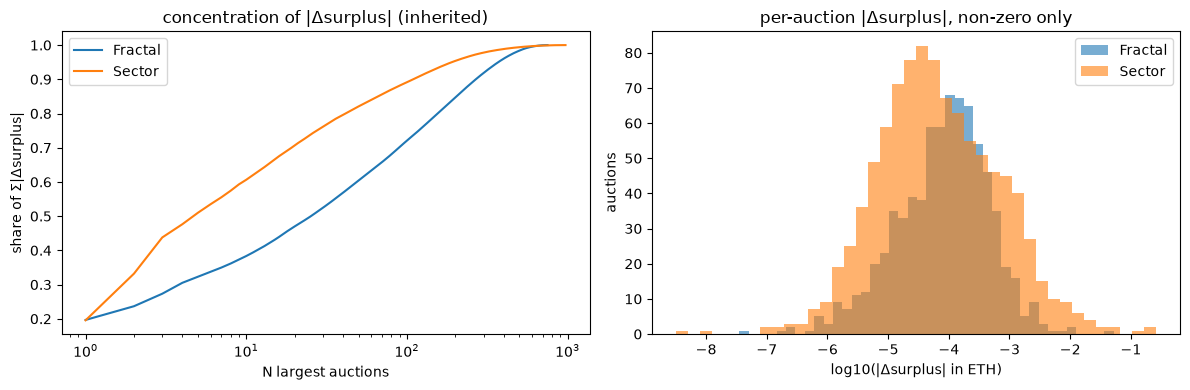

In [5]:
import matplotlib.pyplot as plt
import numpy as np

fig, (concentration, histogram) = plt.subplots(1, 2, figsize=(12, 4))

for window in windows:
    deltas = np.array(
        sorted(
            (
                abs(m.delta_surplus) / 1e18
                for m in window.headline.moves
                if m.delta_surplus
            ),
            reverse=True,
        )
    )
    if not deltas.size:
        continue
    concentration.plot(
        np.arange(1, deltas.size + 1),
        deltas.cumsum() / deltas.sum(),
        label=window.solver,
    )
    histogram.hist(
        np.log10(deltas), bins=40, alpha=0.6, label=window.solver
    )

concentration.set_xscale("log")
concentration.set_xlabel("N largest auctions")
concentration.set_ylabel("share of Σ|Δsurplus|")
concentration.set_title("concentration of |Δsurplus| (inherited)")
concentration.legend()
histogram.set_xlabel("log10(|Δsurplus| in ETH)")
histogram.set_ylabel("auctions")
histogram.set_title("per-auction |Δsurplus|, non-zero only")
histogram.legend()
fig.tight_layout()

In [6]:
# The individually-inspectable tail: the ten auctions that move each headline most.
frames = []
for window in windows:
    top = sorted(
        window.headline.moves, key=lambda m: -abs(m.delta_surplus)
    )[:10]
    frames.append(
        pd.DataFrame(
            {
                "solver": window.solver,
                "auction": m.auction_id,
                "Δsurplus [ETH]": m.delta_surplus / 1e18,
                "Δrewards uncapped [ETH]": m.delta_rewards / 1e18,
                "Δrewards capped [ETH]": (
                    float(m.delta_rewards_capped) / 1e18
                    if m.delta_rewards_capped is not None
                    else None
                ),
            }
            for m in top
        )
    )
pd.concat(frames, ignore_index=True).round(6)

,solver,auction,Δsurplus [ETH],Δrewards uncapped [ETH],Δrewards capped [ETH]
0,Fractal,13509837,0.051759,0.072475,0.010363
1,Fractal,13504867,0.010533,-0.021466,-0.021466
2,Fractal,13493892,0.009615,-0.007396,0.000000
3,Fractal,13507008,0.008387,-0.209163,0.000000
4,Fractal,13503828,0.004693,0.005215,0.000261
5,Fractal,13504820,0.003882,0.005525,0.002321
6,Fractal,13506851,0.003158,0.005632,0.001237
7,Fractal,13495832,0.003109,0.007075,0.001983
8,Fractal,13507246,0.003016,0.005986,0.001485
9,Fractal,13497490,0.002749,0.007058,0.001938


## How to read the result

- **Δsurplus** is the change in what users receive when the solver is removed, under
  the competition's own decisions and the named settlement rule.
- **Δrewards (capped)** is the change in payout-scale payments — quote this one as
  money. **Δrewards (uncapped)** is the change in the mechanism's internal
  accounting — quote it only as such.
- **Net change** = Δsurplus − capped Δrewards: what the removal scenario does to
  users and the protocol treasury combined, per the labels above. How any of these
  changes translates into a *value of the solver* is the reader's step, not the
  pipeline's (D16).
- **Orders executed only with the solver** is the coverage answer. Its converse is
  legitimately non-zero — a removed winner can stop blocking a rival's multi-order
  batch
  ([mechanism](../docs/winner-selection.md#a-blocked-batch-keeps-orders-unexecuted)).

The full write-up of the measured window, with the numbers this notebook reproduces,
is [PLAN §7.1](../PLAN.md#71-m4-result).